# **Forgery Detection**

In [1]:
!pip install kaggle --quiet

In [2]:
import json
import os
from google.colab import userdata
kaggle_dict={
    "username":userdata.get("KAGGLE_USERNAME"),
    "key":userdata.get('Key')
}

os.makedirs("/root/.kaggle",exist_ok=True)

with open("/root/.kaggle/kaggle.json","w") as f:
  json.dump(kaggle_dict,f)

! chmod 600 /root/.kaggle/kaggle.json

# from google.colab import files
# files.upload()

# import os
# os.makedirs("/roots/.kaggle",exist_ok=True)
# !mv kaggle.json /root/.kaggle/
# !chmod 600 /root/.kaggle/kaggle.json
# print("kaggle auth ready ")

In [3]:
# CASIA v2
!kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset \
    --unzip -p /content/casia

# CASIA ground truth
!git clone https://github.com/SunnyHaze/CASIA2.0-Corrected-Groundtruth \
    /content/casia/groundtruth


Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
 99% 2.53G/2.56G [00:40<00:00, 121MB/s]
100% 2.56G/2.56G [00:40<00:00, 68.1MB/s]
Cloning into '/content/casia/groundtruth'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 38 (delta 10), reused 22 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 1.04 MiB | 3.51 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [4]:
from datasets import load_dataset
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

#loading the dataset and sacing on disk
dataset=load_dataset("dvgodoy/rvl_cdip_mini", split="train")
dataset.save_to_disk("/content/rvlcdip")
print(f"toatal images:{len(dataset)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/341M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/41.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3200 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3200 [00:00<?, ? examples/s]

toatal images:3200


In [5]:
import os
from datasets import load_from_disk

AUTH_DIR = "/content/casia/CASIA2/Au"
TAMP_DIR = "/content/casia/CASIA2/Tp"
MASK_DIR = "/content/casia/CASIA2/CASIA 2 Groundtruth"

print("CASIA authentic :", len(os.listdir(AUTH_DIR)))
print("CASIA tampered  :", len(os.listdir(TAMP_DIR)))
print("Ground truth    :", len(os.listdir(MASK_DIR)))

rvl = load_from_disk("/content/rvlcdip")
print("RVL-CDIP total  :", len(rvl))

CASIA authentic : 7492
CASIA tampered  : 5125
Ground truth    : 5123
RVL-CDIP total  : 3200


In [6]:
import os
import pandas as pd

AUTH_DIR = "/content/casia/CASIA2/Au"
TAMP_DIR = "/content/casia/CASIA2/Tp"
MASK_DIR = "/content/casia/CASIA2/CASIA 2 Groundtruth"

# Build mask lookup — strip _gt for matching
mask_lookup = {}
for f in os.listdir(MASK_DIR):
    base = f.replace("_gt.png", "")  # remove _gt suffix
    mask_lookup[base] = os.path.join(MASK_DIR, f)

records = []

# Authentic
for f in os.listdir(AUTH_DIR):
    if not f.lower().endswith((".jpg",".png",".tif",".bmp")):
        continue
    records.append({
        "file_id"        : f.rsplit(".",1)[0],
        "image_path"     : os.path.join(AUTH_DIR, f),
        "mask_path"      : None,
        "is_forged"      : 0,
        "forgery_type"   : "none",
        "source_dataset" : "CASIA_v2"
    })

# Tampered
for f in os.listdir(TAMP_DIR):
    if not f.lower().endswith((".jpg",".png",".tif",".bmp")):
        continue

    base         = f.rsplit(".",1)[0]
    mask_path    = mask_lookup.get(base, None)  # lookup using base name
    forgery_type = "copy_move" if "_CM_" in f or "CRN" in f \
                   else "splicing" if "_S_" in f \
                   else "unknown"

    records.append({
        "file_id"        : base,
        "image_path"     : os.path.join(TAMP_DIR, f),
        "mask_path"      : mask_path,
        "is_forged"      : 1,
        "forgery_type"   : forgery_type,
        "source_dataset" : "CASIA_v2"
    })

# RVL-CDIP
from datasets import load_from_disk
rvl = load_from_disk("/content/rvlcdip")

for i, sample in enumerate(rvl):
    records.append({
        "file_id"        : f"rvlcdip_{i:05d}",
        "image_path"     : f"rvlcdip_index_{i}",
        "mask_path"      : None,
        "is_forged"      : 0,
        "forgery_type"   : "none",
        "source_dataset" : "RVL_CDIP"
    })

# Build dataframe
df = pd.DataFrame(records)
df.to_csv("/content/master_labels.csv", index=False)

print(f"Total records : {len(df)}")
print(f"Authentic     : {len(df[df.is_forged==0])}")
print(f"Forged        : {len(df[df.is_forged==1])}")
print(f"With mask     : {df.mask_path.notna().sum()}")
print(f"\nForgery types:\n{df.forgery_type.value_counts()}")
print(f"\nSources:\n{df.source_dataset.value_counts()}")


Total records : 15814
Authentic     : 10691
Forged        : 5123
With mask     : 4981

Forgery types:
forgery_type
none         10691
splicing      3929
unknown        662
copy_move      532
Name: count, dtype: int64

Sources:
source_dataset
CASIA_v2    12614
RVL_CDIP     3200
Name: count, dtype: int64


In [7]:
df[7500:7550]

,file_id,image_path,mask_path,is_forged,forgery_type,source_dataset
7500,Tp_D_CRD_M_N_arc00037_ani00005_10142,/content/casia/CASIA2/Tp/Tp_D_CRD_M_N_arc00037...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,unknown,CASIA_v2
7501,Tp_S_NND_S_N_ind00100_ind00100_01379,/content/casia/CASIA2/Tp/Tp_S_NND_S_N_ind00100...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7502,Tp_D_NRN_M_N_ani10144_nat10156_12472,/content/casia/CASIA2/Tp/Tp_D_NRN_M_N_ani10144...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,unknown,CASIA_v2
7503,Tp_S_NND_S_B_art00075_art00075_01245,/content/casia/CASIA2/Tp/Tp_S_NND_S_B_art00075...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7504,Tp_D_NRN_M_N_nat00033_cha00070_11476,/content/casia/CASIA2/Tp/Tp_D_NRN_M_N_nat00033...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,unknown,CASIA_v2
7505,Tp_S_NRN_S_N_arc20070_arc20070_01710,/content/casia/CASIA2/Tp/Tp_S_NRN_S_N_arc20070...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7506,Tp_D_NRN_S_N_cha00085_ind00098_10851,/content/casia/CASIA2/Tp/Tp_D_NRN_S_N_cha00085...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,splicing,CASIA_v2
7507,Tp_S_NRN_S_N_arc00081_arc00081_00301,/content/casia/CASIA2/Tp/Tp_S_NRN_S_N_arc00081...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7508,Tp_D_NNN_S_B_arc20098_arc20030_02198,/content/casia/CASIA2/Tp/Tp_D_NNN_S_B_arc20098...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,splicing,CASIA_v2
7509,Tp_S_CRN_S_B_cha00021_cha00021_20025,/content/casia/CASIA2/Tp/Tp_S_CRN_S_B_cha00021...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,copy_move,CASIA_v2


Current dataset:

CASIA    → forged general images (nature, animals, objects)

RVL-CDIP → real documents only, NO forgeries

Problem:

Model has never seen a FORGED DOCUMENT

It only knows:
→ what forged general images look like

→ what real documents look like

→ never seen forged prescription/document

Solution:
Take RVL-CDIP real documents

Artificially forge them

So model learns document-specific forgery patterns


Real Document (RVL-CDIP)

        ↓
3 types of forgeries:


Type 1: Copy-Move

→ Copy a number/text region from same document

→ Paste it elsewhere in same document

→ e.g. copy "100" paste over "900"


Type 2: Splicing  

→ Take a region from another document

→ Paste into current document

→ e.g. paste different doctor stamp

Type 3: Text Region Tampering

→ Brighten/darken specific text area

→ Simulates erasing and rewriting

In [8]:
import torch
print(torch.cuda.is_available())

True


In [9]:
import cv2
import numpy as np
import pandas as pd
from datasets import load_from_disk
from PIL import Image
from tqdm import tqdm

#load the RVL-CDIP dataset from disk
rvl=load_from_disk("/content/rvlcdip")

# output directpries
os.makedirs("/content/synthetic/forged",exist_ok=True)
os.makedirs("/content/synthetic/masks",exist_ok=True)

rvl = load_from_disk("/content/rvlcdip")
print(f"generating forgery images for {len(rvl)} documents...")

generating forgery images for 3200 documents...


In [10]:
def generate_copy_move(image):
    """
    Copy a region from document and paste elsewhere
    Simulates: copying a number and pasting over another
    """
    img    = np.array(image.convert("RGB"))
    h, w   = img.shape[:2]
    mask   = np.zeros((h, w), dtype=np.uint8)

    # Random source region (copy from here)
    src_x  = np.random.randint(0, w // 2)
    src_y  = np.random.randint(0, h // 2)
    rw     = np.random.randint(30, w // 4)
    rh     = np.random.randint(10, h // 4)

    # Make sure region fits
    rw     = min(rw, w - src_x)
    rh     = min(rh, h - src_y)

    # Copy region
    region = img[src_y:src_y+rh, src_x:src_x+rw].copy()

    # Random destination (paste here)
    dst_x  = np.random.randint(0, w - rw)
    dst_y  = np.random.randint(0, h - rh)

    # Paste with slight blur to blend
    blurred = cv2.GaussianBlur(region, (3, 3), 0)
    img[dst_y:dst_y+rh, dst_x:dst_x+rw] = blurred

    # Mark tampered region in mask
    mask[dst_y:dst_y+rh, dst_x:dst_x+rw] = 255

    return img, mask

In [11]:
def generate_splicing(image1, image2):
    """
    Take region from doc1, paste into doc2
    Simulates: pasting different stamp/signature
    """
    img1   = np.array(image1.convert("RGB"))
    img2   = np.array(image2.convert("RGB"))
    h, w   = img1.shape[:2]
    mask   = np.zeros((h, w), dtype=np.uint8)

    # Resize img2 to match img1 if needed
    img2   = cv2.resize(img2, (w, h))

    # Random region from img2
    src_x  = np.random.randint(0, w // 2)
    src_y  = np.random.randint(0, h // 2)
    rw     = np.random.randint(30, w // 3)
    rh     = np.random.randint(10, h // 3)

    rw     = min(rw, w - src_x)
    rh     = min(rh, h - src_y)

    region = img2[src_y:src_y+rh, src_x:src_x+rw].copy()

    # Paste into img1 at random location
    dst_x  = np.random.randint(0, w - rw)
    dst_y  = np.random.randint(0, h - rh)

    img1[dst_y:dst_y+rh, dst_x:dst_x+rw] = region

    # Mark tampered region
    mask[dst_y:dst_y+rh, dst_x:dst_x+rw] = 255

    return img1, mask

In [12]:
def generate_text_tampering(image):
    """
    Brighten a text region — simulates erasing and rewriting
    """
    img    = np.array(image.convert("RGB"))
    h, w   = img.shape[:2]
    mask   = np.zeros((h, w), dtype=np.uint8)

    # Random narrow horizontal region (simulates a text line)
    x      = np.random.randint(0, w // 2)
    y      = np.random.randint(0, h - 20)
    rw     = np.random.randint(50, w // 2)
    rh     = np.random.randint(10, 30)   # narrow = one text line

    rw     = min(rw, w - x)
    rh     = min(rh, h - y)

    # Brighten that region (simulates whitening out text)
    region = img[y:y+rh, x:x+rw].astype(np.float32)
    region = np.clip(region * 1.8, 0, 255).astype(np.uint8)
    img[y:y+rh, x:x+rw] = region

    mask[y:y+rh, x:x+rw] = 255

    return img, mask

In [13]:
# Generate forgeries for all RVL-CDIP documents
synthetic_records = []
forgery_types     = ["copy_move", "splicing", "text_tamper"]

for i, sample in enumerate(tqdm(rvl, desc="Generating forgeries")):
    image        = sample["image"]
    forgery_type = forgery_types[i % 3]  # rotate between 3 types

    try:
        if forgery_type == "copy_move":
            forged_img, mask = generate_copy_move(image)

        elif forgery_type == "splicing":
            # Pick random different document for splicing
            j            = (i + np.random.randint(1, 100)) % len(rvl)
            image2       = rvl[j]["image"]
            forged_img, mask = generate_splicing(image, image2)

        else:
            forged_img, mask = generate_text_tampering(image)

        # Save forged image
        img_path  = f"/content/synthetic/forged/syn_{i:05d}.png"
        mask_path = f"/content/synthetic/masks/syn_{i:05d}_mask.png"

        cv2.imwrite(img_path,  cv2.cvtColor(forged_img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(mask_path, mask)

        synthetic_records.append({
            "file_id"        : f"syn_{i:05d}",
            "image_path"     : img_path,
            "mask_path"      : mask_path,
            "is_forged"      : 1,
            "forgery_type"   : forgery_type,
            "source_dataset" : "SYNTHETIC"
        })

    except Exception as e:
        print(f"Failed {i}: {e}")
        continue

print(f"Generated {len(synthetic_records)} synthetic forgeries ✓")

Generating forgeries: 100%|██████████| 3200/3200 [01:26<00:00, 36.98it/s]

Generated 3200 synthetic forgeries ✓


In [14]:
# Merge synthetic records into master CSV
master_df    = pd.read_csv("/content/master_labels.csv")
synthetic_df = pd.DataFrame(synthetic_records)
final_df     = pd.concat([master_df, synthetic_df], ignore_index=True)
final_df.to_csv("/content/master_labels.csv", index=False)

print(f"Updated master CSV:")
print(f"Total          : {len(final_df)}")
print(f"Authentic      : {len(final_df[final_df.is_forged==0])}")
print(f"Forged         : {len(final_df[final_df.is_forged==1])}")
print(f"Sources        :\n{final_df.source_dataset.value_counts()}")
print(f"Forgery types  :\n{final_df.forgery_type.value_counts()}")


Updated master CSV:
Total          : 19014
Authentic      : 10691
Forged         : 8323
Sources        :
source_dataset
CASIA_v2     12614
RVL_CDIP      3200
SYNTHETIC     3200
Name: count, dtype: int64
Forgery types  :
forgery_type
none           10691
splicing        4996
copy_move       1599
text_tamper     1066
unknown          662
Name: count, dtype: int64


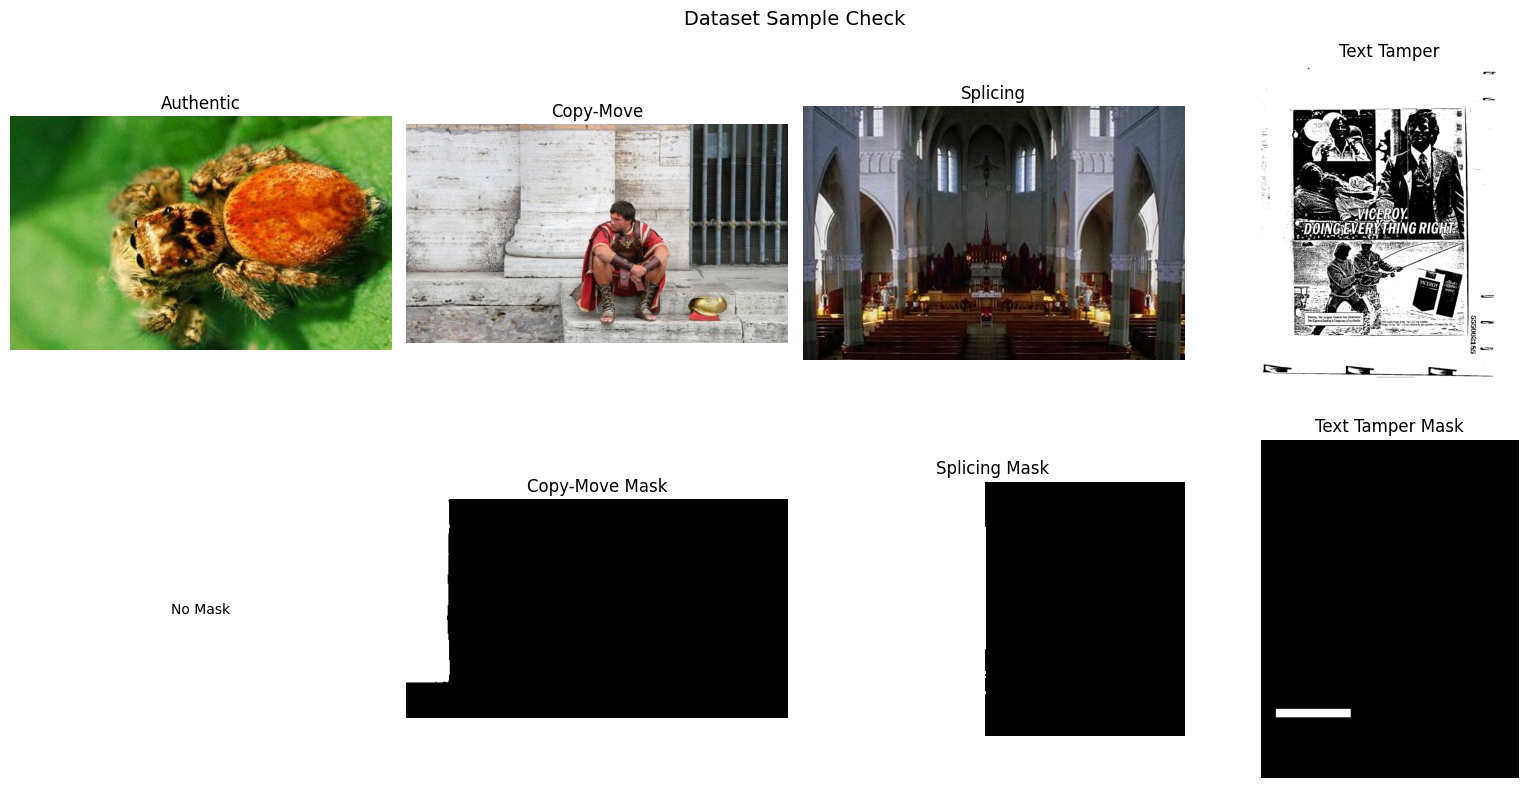

Sanity check complete ✓


In [15]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

df = pd.read_csv("/content/master_labels.csv")

# Pick one sample from each type
authentic  = df[df.forgery_type == "none"].iloc[0]
copy_move  = df[df.forgery_type == "copy_move"].iloc[0]
splicing   = df[df.forgery_type == "splicing"].iloc[0]
text_tamp  = df[df.forgery_type == "text_tamper"].iloc[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Dataset Sample Check", fontsize=14)

samples = [authentic, copy_move, splicing, text_tamp]
titles  = ["Authentic", "Copy-Move", "Splicing", "Text Tamper"]

for i, (sample, title) in enumerate(zip(samples, titles)):
    # Show image
    img = cv2.imread(sample["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img)
    axes[0][i].set_title(title)
    axes[0][i].axis("off")

    # Show mask if exists
    if pd.notna(sample["mask_path"]):
        mask = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)
        axes[1][i].imshow(mask, cmap="gray")
        axes[1][i].set_title(f"{title} Mask")
    else:
        axes[1][i].text(0.5, 0.5, "No Mask",
                        ha="center", va="center")
    axes[1][i].axis("off")

plt.tight_layout()
plt.savefig("/content/dataset_check.png")
plt.show()
print("Sanity check complete ✓")

In [16]:
import torch
print("GPU       :", torch.cuda.get_device_name(0))
print("Memory    :", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2), "GB")
print("PyTorch   :", torch.__version__)

GPU       : Tesla T4
Memory    : 15.64 GB
PyTorch   : 2.10.0+cu128


In [17]:
import pandas as pd
df=pd.read_csv('master_labels.csv')
print(df.head())
print(df.is_forged.value_counts())

        file_id                                 image_path mask_path  \
0  Au_ani_10165  /content/casia/CASIA2/Au/Au_ani_10165.jpg       NaN   
1  Au_nat_30298  /content/casia/CASIA2/Au/Au_nat_30298.jpg       NaN   
2  Au_art_10012  /content/casia/CASIA2/Au/Au_art_10012.jpg       NaN   
3  Au_cha_30473  /content/casia/CASIA2/Au/Au_cha_30473.jpg       NaN   
4  Au_pla_30600  /content/casia/CASIA2/Au/Au_pla_30600.jpg       NaN   

   is_forged forgery_type source_dataset  
0          0         none       CASIA_v2  
1          0         none       CASIA_v2  
2          0         none       CASIA_v2  
3          0         none       CASIA_v2  
4          0         none       CASIA_v2  
is_forged
0    10691
1     8323
Name: count, dtype: int64


In [18]:
!pip install timm scikit-learn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


**Dataset Loader**

In [19]:
from datasets import load_from_disk

# Load RVL-CDIP once globally
rvl_dataset = load_from_disk("/content/rvlcdip")

class ForgeryDataset(Dataset):
    def __init__(self, df, transform=None, mask_size=(128, 128)):
        # Only use rows with valid image paths
        self.df         = df.reset_index(drop=True)
        self.transform  = transform
        self.mask_size  = mask_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Load image ───────────────────────────────────────────
        try:
            if str(row["image_path"]).startswith("rvlcdip_index_"):
                # Load from HuggingFace dataset
                i     = int(str(row["image_path"]).split("_")[-1])
                image = rvl_dataset[i]["image"].convert("RGB")
                image = np.array(image)
            else:
                image = cv2.imread(row["image_path"])
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            image = cv2.resize(image, (224, 224))
            image = Image.fromarray(image)

            if self.transform:
                image = self.transform(image)

        except Exception:
            image = torch.zeros(3, 224, 224)

        # ── Load mask ────────────────────────────────────────────
        try:
            if pd.notna(row["mask_path"]):
                mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, self.mask_size)
                mask = torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0)
            else:
                mask = torch.zeros(1, *self.mask_size)
        except Exception:
            mask = torch.zeros(1, *self.mask_size)

        # ── Labels ───────────────────────────────────────────────
        is_forged    = torch.tensor(row["is_forged"], dtype=torch.float32)
        has_mask     = torch.tensor(1.0 if pd.notna(row["mask_path"]) else 0.0)

        return image, mask, is_forged, has_mask

**Model Architecture**

In [20]:
import torch
import torch.nn as nn
import timm
import numpy as np
from PIL import Image
import io

class ForgeryDetector(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Backbone — EfficientNet B4 pretrained ────────────────
        self.backbone = timm.create_model(
            "efficientnet_b4",
            pretrained=True,
            features_only=True,
            out_indices=[1, 2, 3, 4]
        )

        # ── Detect actual backbone output channels automatically ──
        with torch.no_grad():
            dummy     = torch.zeros(1, 3, 224, 224)
            features  = self.backbone(dummy)
            last_feat = features[-1]
            channels  = last_feat.shape[1]
            h, w      = last_feat.shape[2], last_feat.shape[3]
            print(f"Backbone output channels : {channels}")
            print(f"Backbone output shape    : {last_feat.shape}")

        # ── ELA Branch ───────────────────────────────────────────
        # Detects compression artifacts left by editing tools
        self.ela_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )
        ela_out_size = 64

        # ── Classification Head ───────────────────────────────────
        # Takes backbone features → predicts real/fake
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels + ela_out_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
            # ← NO sigmoid here
            # BCEWithLogitsLoss handles sigmoid internally
            # safe for autocast
        )

        # ── Segmentation Head ─────────────────────────────────────
        # Takes backbone features → outputs forgery heatmap
        self.seg_head = nn.Sequential(
            nn.Conv2d(channels, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
            # ← NO sigmoid here
            # BCEWithLogitsLoss handles it internally
            # safe for autocast
        )

    def compute_ela(self, x, quality=90):
        """
        Error Level Analysis
        Recompress image at known quality
        Difference reveals tampered regions
        Tampered areas have different compression noise
        """
        ela_imgs = []
        for img in x:
            try:
                # Convert tensor to numpy image
                img_np  = (
                    img.permute(1, 2, 0)
                    .cpu()
                    .float()
                    .numpy() * 255
                ).astype(np.uint8)

                pil_img = Image.fromarray(img_np)

                # Recompress at known quality level
                buf = io.BytesIO()
                pil_img.save(buf, format="JPEG", quality=quality)
                buf.seek(0)
                recompressed = np.array(
                    Image.open(buf)
                ).astype(np.float32)

                # Difference = ELA map
                ela = np.abs(
                    img_np.astype(np.float32) - recompressed
                )

                # Normalize to 0-1
                if ela.max() > 0:
                    ela = ela / ela.max()

                ela_imgs.append(
                    torch.tensor(ela)
                    .permute(2, 0, 1)
                    .float()
                )

            except Exception:
                # If ELA fails return zeros
                ela_imgs.append(torch.zeros(3, 224, 224))

        return torch.stack(ela_imgs).to(x.device)

    def forward(self, x):
        # ── Backbone features ─────────────────────────────────────
        features  = self.backbone(x)
        last_feat = features[-1]          # deepest feature map

        # ── ELA features ──────────────────────────────────────────
        ela       = self.compute_ela(x)   # (B, 3, 224, 224)
        ela_feat  = self.ela_conv(ela)    # (B, 64)

        # ── Classification ────────────────────────────────────────
        pooled    = self.global_pool(last_feat)   # (B, channels, 1, 1)
        pooled    = pooled.view(pooled.size(0), -1)  # (B, channels)

        # Combine backbone + ELA features
        combined  = torch.cat([pooled, ela_feat], dim=1)  # (B, channels+64)
        cls_out   = self.classifier(combined)              # (B, 1)
        cls_out   = cls_out.squeeze(1)                     # (B,)

        # ── Segmentation ──────────────────────────────────────────
        seg_out   = self.seg_head(last_feat)   # (B, 1, H, W)

        return cls_out, seg_out   # both raw logits, no sigmoid


# ── Build model ───────────────────────────────────────────────────────────────
import gc
gc.collect()
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = ForgeryDetector().to(DEVICE)

print(f"\nModel ready ✓")
print(f"Device     : {DEVICE}")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Backbone output channels : 448
Backbone output shape    : torch.Size([1, 448, 7, 7])

Model ready ✓
Device     : cuda
Parameters : 17,765,962


Transform + DataLoaders

In [21]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load master CSV
df = pd.read_csv("/content/master_labels.csv")

# Remove RVL-CDIP from validation — keep only disk images for val
disk_df  = df[~df["image_path"].str.startswith("rvlcdip_index_", na=False)]
rvl_df   = df[df["image_path"].str.startswith("rvlcdip_index_", na=False)]

# Split disk images
train_disk, val_df = train_test_split(
    disk_df, test_size=0.2,
    stratify=disk_df["is_forged"],
    random_state=42
)

# Add RVL-CDIP to train only
train_df = pd.concat([train_disk, rvl_df], ignore_index=True)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")

# Datasets
train_dataset = ForgeryDataset(train_df, transform=transform_train)
val_dataset   = ForgeryDataset(val_df,   transform=transform_val)

# Recreate DataLoaders with smaller batch size
train_loader = DataLoader(
    train_dataset,
    batch_size=8,        # ← reduced from 32 to 8
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,        # ← reduced from 32 to 8
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train : 15851
Val   : 3163
Train batches : 1982
Val batches   : 396


Training loops

In [22]:
from torch.cuda.amp import autocast, GradScaler

scaler             = GradScaler()
ACCUMULATION_STEPS = 4

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()

    for i, (images, masks, labels, has_mask) in enumerate(tqdm(loader, desc="Training")):
        images   = images.to(DEVICE)
        masks    = masks.to(DEVICE)
        labels   = labels.to(DEVICE)
        has_mask = has_mask.to(DEVICE)

        with autocast():
            cls_out, seg_out = model(images)
            cls_loss         = cls_criterion(cls_out, labels)

            seg_loss = torch.tensor(0.0).to(DEVICE)
            mask_idx = has_mask.bool()
            if mask_idx.sum() > 0:
                seg_out_masked = seg_out[mask_idx]
                target_masks   = nn.functional.interpolate(
                    masks[mask_idx],
                    size=seg_out_masked.shape[2:],
                    mode="bilinear", align_corners=False
                )
                seg_loss = seg_criterion(seg_out_masked, target_masks)

            loss = (cls_loss + 0.5 * seg_loss) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        # ✅ Fix 3 — handle last batch
        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ACCUMULATION_STEPS
        preds       = (torch.sigmoid(cls_out) > 0.5).float()  # ✅ Fix 1
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if i % 50 == 0:
            torch.cuda.empty_cache()

    return total_loss / len(loader), correct / total


def val_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, masks, labels, has_mask in tqdm(loader, desc="Validation"):
            images   = images.to(DEVICE)
            masks    = masks.to(DEVICE)
            labels   = labels.to(DEVICE)
            has_mask = has_mask.to(DEVICE)

            with autocast():                              # ✅ Fix 2
                cls_out, seg_out = model(images)
                cls_loss         = cls_criterion(cls_out, labels)

                seg_loss = torch.tensor(0.0).to(DEVICE)
                mask_idx = has_mask.bool()
                if mask_idx.sum() > 0:
                    seg_out_masked = seg_out[mask_idx]
                    target_masks   = nn.functional.interpolate(
                        masks[mask_idx],
                        size=seg_out_masked.shape[2:],
                        mode="bilinear", align_corners=False
                    )
                    seg_loss = seg_criterion(seg_out_masked, target_masks)

            loss        = cls_loss + 0.5 * seg_loss
            total_loss += loss.item()
            preds       = (torch.sigmoid(cls_out) > 0.5).float()  # ✅ Fix 1
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

print("Training functions ready ✓")


Training functions ready ✓


**Run Training**

In [23]:
import torch.optim as optim

# ── Class weights to handle imbalance ────────────────────────────
authentic_count = len(df[df.is_forged == 0])
forged_count    = len(df[df.is_forged == 1])
pos_weight      = torch.tensor([authentic_count / forged_count]).to(DEVICE)

# ── Loss functions ────────────────────────────────────────────────
cls_criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
seg_criterion   = nn.BCEWithLogitsLoss()

# ── Optimizer ─────────────────────────────────────────────────────
optimizer       = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ── Scheduler ─────────────────────────────────────────────────────
scheduler       = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

print(f"Authentic count : {authentic_count}")
print(f"Forged count    : {forged_count}")
print(f"Pos weight      : {pos_weight.item():.4f}")
print("Optimizer ready ✓")

Authentic count : 10691
Forged count    : 8323
Pos weight      : 1.2845
Optimizer ready ✓



Epoch 1/10


Validation: 100%|██████████| 396/396 [00:39<00:00,  9.99it/s]


Train Loss: 0.8532 | Train Acc: 0.5961
Val Loss  : 0.7528   | Val Acc  : 0.7430
Best model saved ✓  val_acc: 0.7430

Epoch 2/10


Validation: 100%|██████████| 396/396 [00:38<00:00, 10.24it/s]


Train Loss: 0.7863 | Train Acc: 0.6451
Val Loss  : 0.7402   | Val Acc  : 0.7373
No improvement 1/3

Epoch 3/10


...

Train Loss: 0.7379 | Train Acc: 0.6657
Val Loss  : 0.6824   | Val Acc  : 0.7540
No improvement 1/3

Epoch 5/10


Validation: 100%|██████████| 396/396 [00:36<00:00, 10.91it/s]


Train Loss: 0.7196 | Train Acc: 0.6786
Val Loss  : 0.6893   | Val Acc  : 0.7480
No improvement 2/3

Epoch 6/10


Validation: 100%|██████████| 396/396 [00:37<00:00, 10.69it/s]


Train Loss: 0.6972 | Train Acc: 0.6885
Val Loss  : 0.7893   | Val Acc  : 0.6876
No improvement 3/3

Early stopping triggered at epoch 6

Training Complete. Best Val Accuracy: 0.7714


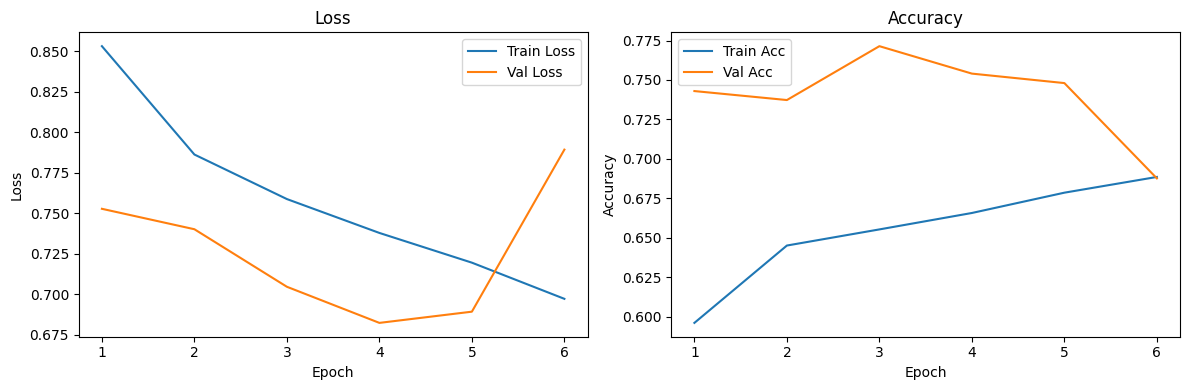

Plot saved ✓


In [24]:
import matplotlib.pyplot as plt

EPOCHS        = 10
best_val      = 0
history       = []
patience      = 3       # stop if no improvement for 3 epochs
no_improve    = 0       # counter

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_loss,   val_acc   = val_epoch(model, val_loader)
    scheduler.step()

    history.append({
        "epoch"      : epoch + 1,
        "train_loss" : train_loss,
        "train_acc"  : train_acc,
        "val_loss"   : val_loss,
        "val_acc"    : val_acc
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f}   | Val Acc  : {val_acc:.4f}")

    # ── Save best model ───────────────────────────────────────────
    if val_acc > best_val:
        best_val   = val_acc
        no_improve = 0
        torch.save(model.state_dict(), "/content/best_model.pth")
        print(f"Best model saved ✓  val_acc: {val_acc:.4f}")
    else:
        no_improve += 1
        print(f"No improvement {no_improve}/{patience}")

    # ── Early stopping ────────────────────────────────────────────
    if no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining Complete. Best Val Accuracy: {best_val:.4f}")

# ── Plot training history ─────────────────────────────────────────
history_df = pd.DataFrame(history)

fig, axes  = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy plot
axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/training_history.png")
plt.show()
print("Plot saved ✓")
